# Experiment 1: VGC simulations visualization

In [1]:
import json
import random
from itertools import product
import pickle
import os

import tqdm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches


import pickle
plt.rcParams["font.family"] = "Arial"

start_goal_pos = [(8,1),(8,15)]

from vgc_project.construal_search_new import \
    ConstrualSearch, ExhaustiveSearch, BreadthFirstSearch, DepthFirstSearch, \
    EventListener, BoundedDepthFirstSearch
    
def xy_to_rowcol(maze, x, y):
    """
    Convert Cartesian-style maze coordinates:
        (0,0) = bottom-left
    into Python maze indexing:
        maze[row][col], with row 0 = top
    """
    H = len(maze)
    W = len(maze[0])
    if not (0 <= x < W and 0 <= y < H):
        return None
    row = H - 1 - y
    col = x
    return row, col


def rowcol_to_xy(maze, row, col):
    """
    Inverse of xy_to_rowcol.
    """
    H = len(maze)
    y = H - 1 - row
    x = col
    return x, y


def is_traversable(maze, x, y):
    rc = xy_to_rowcol(maze, x, y)
    if rc is None:
        return False
    row, col = rc
    return maze[row][col] in {'.', 'S', 'G'}


def find_char(maze, target):
    """
    Find S or G in the maze and return Cartesian coordinates
    with bottom-left = (0,0).
    """
    H = len(maze)
    for row, line in enumerate(maze):
        for col, ch in enumerate(line):
            if ch == target:
                return rowcol_to_xy(maze, row, col)
    raise ValueError(f"{target} not found in maze")
def location_on_shared_walls(r,c, n_rows, n_cols):
    if(r==1 or r==(n_rows-2)):
        if(c>0 and c<(n_cols-1)):
            return True
    elif(c==1 or c==(n_cols-2)):
        if(r>0 and r<(n_rows-1)):
            return True
    return False
        
def parse_maze_with_numbered_walls(
    maze_arr,
    start=(8,1),
    goal=(8,15),
    wall_start_idx=1,
):
    """
    Convert a maze char array into a labeled object array.

    Parameters
    ----------
    maze_arr : np.ndarray
        2D array from maze_to_char_array(), containing symbols like
        '+', '-', '.', '#'
    start : tuple or None
        (row, col) coordinate to label as 'S'
    goal : tuple or None
        (row, col) coordinate to label as 'G'
    wall_start_idx : int
        Starting integer for numbering '#' cells

    Returns
    -------
    out : np.ndarray
        2D object array of strings, where:
        - '+', '-', '.' become '.'
        - each '#' becomes a unique string integer
        - start becomes 'S'
        - goal becomes 'G'
    """
    maze_arr = np.asarray(maze_arr)
    if maze_arr.ndim != 2:
        raise ValueError(f"maze_arr must be 2D, got shape {maze_arr.shape}")

    n_rows, n_cols = maze_arr.shape
    out = np.empty((n_rows, n_cols), dtype=object)

    wall_counter = wall_start_idx
    
    shared_construal = []

    for r in range(n_rows):
        for c in range(n_cols):
            val = maze_arr[r, c]

            if val in ['+', '-', '.']:
                out[r, c] = '.'
            elif val == '#':
                out[r, c] = str(wall_counter)
                if(location_on_shared_walls(r,c,n_rows,n_cols)): # The shared maze walls across mazes
                    shared_construal.append(wall_counter)
                wall_counter += 1
            else:
                raise ValueError(f"Unexpected maze symbol {val!r} at {(r, c)}")

    # overwrite start / goal after wall numbering
    if start is not None:
        sr, sc = start
        if not (0 <= sr < n_rows and 0 <= sc < n_cols):
            raise ValueError(f"start {start} is out of bounds for maze shape {maze_arr.shape}")
        out[sc, sr] = 'S'

    if goal is not None:
        gr, gc = goal
        if not (0 <= gr < n_rows and 0 <= gc < n_cols):
            raise ValueError(f"goal {goal} is out of bounds for maze shape {maze_arr.shape}")
        out[gc, gr] = 'G'

    return out, shared_construal


def maze_to_char_array(maze):
    return np.array([list(row) for row in maze])


def path_eval_success(path, maze):
    for loc in path:
        if not is_traversable(maze, loc[0], loc[1]):
            return False
    return True


### For VGC, need to have fewer obstacles to exhaustively enumerate. We chunk non-shared wall squares below into 12 chunks. The saved chunked_test_mazes.pkl is needed for the cluster code to run.

In [2]:

def build_two_shared_walls(max_coord=16):
    """
    Construct the two shared maze walls.

    Entry point on rim:  (8, 1)
    Exit point near goal: (8, 15)

    Route A:
      (8,1) -> left along top edge to (8,1)
             -> down left edge to (1,15)
             -> right along bottom edge to (8,15)

    Route B:
      (8,1) -> right along top edge to (15,1)
             -> down right edge to (15,15)
             -> left along bottom edge to (8,15)

    Returns
    -------
    route_left, route_right : sets of (x, y)
    """
    # Left route
    route_left = set()

    # top edge: (8,0) -> (0,0)
    for x in range(1, 8):
        route_left.add((x, 1))

    # left edge: (0,0) -> (0,16)
    for y in range(1, max_coord ):
        route_left.add((1, y))

    # bottom edge: (0,16) -> (8,16)
    for x in range(1, 8):
        route_left.add((x, max_coord-1))

    # Right route
    route_right = set()

    # top edge: (8,0) -> (16,0)
    for x in range(9, max_coord):
        route_right.add((x, 1))

    # right edge: (16,0) -> (16,16)
    for y in range(1, max_coord):
        route_right.add((max_coord-1, y))

    # bottom edge: (16,16) -> (8,16)
    for x in range(9, max_coord):
        route_right.add((x, max_coord-1))

    return route_left, route_right


def label_shared_walls(path, route_left, route_right):
    """
    Label 1 iff the path contains all coordinates of either full rim route.
    """
    path_set = set(path)
    return int(route_left.issubset(path_set) or route_right.issubset(path_set))
import numpy as np

RESERVED = {'.', 'S', 'G', '#'}

OBSTACLE_SYMBOLS = list(
    "abcdefhijklmnopqrtuvwxyz"
    "ABCDEFHIJKLMNOPQRTUVWXYZ"
    "0123456789"
    "!$%&()*+,-/:;<=>?@[]^_{|}~`"
)

EXTRA_SYMBOLS = [chr(i) for i in range(162,260)]

SYMBOL_POOL = [s for s in OBSTACLE_SYMBOLS + EXTRA_SYMBOLS if s not in RESERVED]


def convert_maze_dict_to_vgc_format(maze_dict):

    converted_mazes = {}
    wall_features_by_maze = {}
    obstacle_maps = {}

    for maze_name, arr in maze_dict.items():

        arr = np.asarray(arr, dtype=object)

        obstacle_ids = sorted(
            {str(x) for x in arr.flatten() if str(x) not in RESERVED},
            key=lambda x: int(x) if x.isdigit() else x
        )
        
        if len(obstacle_ids) > len(SYMBOL_POOL):
            raise ValueError("Not enough unique symbols for obstacles.")

        symbol_map = {
            obs: SYMBOL_POOL[i]
            for i, obs in enumerate(obstacle_ids)
        }

        row_strings = []

        for row in arr:
            new_row = "".join(
                str(cell) if str(cell) in RESERVED else symbol_map[str(cell)]
                for cell in row
            )
            row_strings.append(new_row)

        converted_mazes[maze_name] = row_strings
        wall_features_by_maze[maze_name] = "".join(symbol_map.values())
        obstacle_maps[maze_name] = symbol_map

    return converted_mazes, wall_features_by_maze, obstacle_maps


from collections import defaultdict, deque
import heapq
import math


def relabel_maze_wall_chunks(
    maze,
    target_k=12,
    reserved_chars={'.', '#', 'S', 'G'},
    label_pool=None,
):
    """
    Segment wall-symbol cells into human-interpretable chunks and relabel them.

    Rules:
    1) Non-rim chunks are enforced to be contiguous.
    2) Wall-symbol cells OUTSIDE the default # wall are grouped into a left-rim
       chunk and/or a right-rim chunk. These exterior rim chunks are kept
       separate from interior wall chunks.

    Returns
    -------
    relabeled_maze : list[str]
    chunk_cells : dict[int, set[(row, col)]]
    chunk_labels : dict[int, str]
    """

    if label_pool is None:
        pool = (
            list("abcdefghijklmnopqrstuvwxyz")
            + list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
            + list("0123456789")
            + [c for c in "!@$%&*+=?/<>[]{}|~:;" if c not in reserved_chars]
        )
        label_pool = [c for c in pool if c not in reserved_chars]

    H = len(maze)
    W = len(maze[0])
    grid = [list(row) for row in maze]
    DIRS = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    def in_bounds(r, c):
        return 0 <= r < H and 0 <= c < W

    def connected_components(cells):
        cells = set(cells)
        comps = []
        seen = set()
        for start in cells:
            if start in seen:
                continue
            comp = set()
            dq = deque([start])
            seen.add(start)
            while dq:
                x = dq.popleft()
                comp.add(x)
                r, c = x
                for dr, dc in DIRS:
                    nb = (r + dr, c + dc)
                    if nb in cells and nb not in seen:
                        seen.add(nb)
                        dq.append(nb)
            comps.append(comp)
        return comps

    # wall cells to be chunked = any non-reserved symbol
    wall_cells_all = {
        (r, c)
        for r in range(H)
        for c in range(W)
        if grid[r][c] not in reserved_chars
    }

    if not wall_cells_all:
        return maze[:], {}, {}

    # ---------------------------------------------------------
    # A. Find OUTSIDE region, but do NOT allow flood fill through #, S, or G
    # ---------------------------------------------------------
    exterior_blockers = {'#', 'S', 'G'}
    exterior_reachable = set()
    dq = deque()

    boundary_cells = []
    for c in range(W):
        boundary_cells.append((0, c))
        boundary_cells.append((H - 1, c))
    for r in range(1, H - 1):
        boundary_cells.append((r, 0))
        boundary_cells.append((r, W - 1))

    for r, c in boundary_cells:
        if grid[r][c] not in exterior_blockers and (r, c) not in exterior_reachable:
            exterior_reachable.add((r, c))
            dq.append((r, c))

    while dq:
        r, c = dq.popleft()
        for dr, dc in DIRS:
            rr, cc = r + dr, c + dc
            if (
                in_bounds(rr, cc)
                and grid[rr][cc] not in exterior_blockers
                and (rr, cc) not in exterior_reachable
            ):
                exterior_reachable.add((rr, cc))
                dq.append((rr, cc))

    # exterior wall-symbol cells only
    exterior_wall_cells = wall_cells_all & exterior_reachable

    # split only those exterior wall cells into left vs right rim
    start_cols = [c for r in range(H) for c in range(W) if grid[r][c] == 'S']
    divider_col = start_cols[0] if start_cols else (W // 2)

    left_rim_cells = {(r, c) for (r, c) in exterior_wall_cells if c < divider_col}
    right_rim_cells = {(r, c) for (r, c) in exterior_wall_cells if c > divider_col}
    middle_cells = {(r, c) for (r, c) in exterior_wall_cells if c == divider_col}
    for cell in middle_cells:
        # arbitrary but stable tie-break
        right_rim_cells.add(cell)

    # ordinary cells are all non-rim wall cells
    segmentable_cells = wall_cells_all - left_rim_cells - right_rim_cells

    n_special = int(bool(left_rim_cells)) + int(bool(right_rim_cells))
    target_nonrim_k = max(0, target_k - n_special)

    # ---------------------------------------------------------
    # B. Build graph on ordinary segmentable cells
    # ---------------------------------------------------------
    nbrs = {}
    for cell in segmentable_cells:
        r, c = cell
        nbrs[cell] = []
        for dr, dc in DIRS:
            rr, cc = r + dr, c + dc
            if (rr, cc) in segmentable_cells:
                nbrs[cell].append((rr, cc))

    degree = {cell: len(nbrs[cell]) for cell in segmentable_cells}

    def is_turn(cell):
        if degree[cell] != 2:
            return False
        (r1, c1), (r2, c2) = nbrs[cell]
        dr1, dc1 = r1 - cell[0], c1 - cell[1]
        dr2, dc2 = r2 - cell[0], c2 - cell[1]
        return not (dr1 == -dr2 and dc1 == -dc2)

    def is_cutpoint(cell):
        return degree[cell] != 2 or is_turn(cell)

    cutpoints = {cell for cell in segmentable_cells if is_cutpoint(cell)}

    # ---------------------------------------------------------
    # C. Atomic segments
    # ---------------------------------------------------------
    visited_edges = set()
    atomic_segments = []

    def edge_key(a, b):
        return tuple(sorted((a, b)))

    for cp in cutpoints:
        for nb in nbrs[cp]:
            ek = edge_key(cp, nb)
            if ek in visited_edges:
                continue

            seg = [cp]
            prev = cp
            curr = nb
            visited_edges.add(ek)

            while True:
                seg.append(curr)
                if curr in cutpoints and curr != cp:
                    break

                next_candidates = [x for x in nbrs[curr] if x != prev]
                if not next_candidates or len(next_candidates) > 1:
                    break

                nxt = next_candidates[0]
                ek2 = edge_key(curr, nxt)
                if ek2 in visited_edges:
                    break
                visited_edges.add(ek2)
                prev, curr = curr, nxt

            atomic_segments.append(tuple(seg))

    # cutpoint-free loops
    unvisited_loop_cells = set(segmentable_cells)
    for seg in atomic_segments:
        for x in seg:
            unvisited_loop_cells.discard(x)

    while unvisited_loop_cells:
        start = next(iter(unvisited_loop_cells))
        loop = [start]
        unvisited_loop_cells.remove(start)

        prev = None
        curr = start
        while True:
            options = [x for x in nbrs[curr] if x != prev]
            if not options:
                break
            nxt = options[0]
            if nxt == start or nxt not in unvisited_loop_cells:
                break
            loop.append(nxt)
            unvisited_loop_cells.remove(nxt)
            prev, curr = curr, nxt

        atomic_segments.append(tuple(loop))

    # deduplicate
    seen_seg_sets = set()
    deduped_segments = []
    for seg in atomic_segments:
        key = frozenset(seg)
        if key not in seen_seg_sets:
            seen_seg_sets.add(key)
            deduped_segments.append(seg)
    atomic_segments = deduped_segments

    chunk_cells = {i: set(seg) for i, seg in enumerate(atomic_segments)}
    active = set(chunk_cells.keys())

    cell_to_chunks = defaultdict(set)
    for cid, cells in chunk_cells.items():
        for cell in cells:
            cell_to_chunks[cell].add(cid)

    def rebuild_adjacency():
        adjacency = {cid: set() for cid in active}
        for cid in active:
            for cell in chunk_cells[cid]:
                for nb in nbrs.get(cell, []):
                    for other in cell_to_chunks[nb]:
                        if other != cid and other in active:
                            adjacency[cid].add(other)
        return adjacency

    def chunk_orientation(cells):
        rows = [r for r, _ in cells]
        cols = [c for _, c in cells]
        hrange = max(cols) - min(cols) if cols else 0
        vrange = max(rows) - min(rows) if rows else 0
        if hrange > 0 and vrange > 0 and min(hrange, vrange) >= 1:
            ratio = max(hrange, vrange) / max(1, min(hrange, vrange))
            if ratio < 2.5:
                return "mixed"
        if hrange > vrange:
            return "h"
        elif vrange > hrange:
            return "v"
        else:
            return "mixed"

    def chunk_boundary_junction_count(cells):
        return sum(1 for x in cells if degree.get(x, 0) >= 3)

    def chunk_centroid(cells):
        rs = [r for r, _ in cells]
        cs = [c for _, c in cells]
        return (sum(rs) / len(rs), sum(cs) / len(cs))

    def merge_cost(a, b):
        cells_a = chunk_cells[a]
        cells_b = chunk_cells[b]

        ori_a = chunk_orientation(cells_a)
        ori_b = chunk_orientation(cells_b)
        size_penalty = abs(len(cells_a) - len(cells_b)) / max(len(cells_a) + len(cells_b), 1)
        orientation_penalty = 0.0 if ori_a == ori_b else (0.7 if "mixed" in (ori_a, ori_b) else 1.2)
        junc_penalty = 0.4 * (
            max(0, chunk_boundary_junction_count(cells_a) - 1)
            + max(0, chunk_boundary_junction_count(cells_b) - 1)
        )
        centroid_dist = math.dist(chunk_centroid(cells_a), chunk_centroid(cells_b)) / 10.0
        return orientation_penalty + size_penalty + junc_penalty + centroid_dist

    adjacency = rebuild_adjacency()

    # ---------------------------------------------------------
    # D. Greedy merging for ordinary chunks
    # ---------------------------------------------------------
    next_chunk_id = len(chunk_cells)

    while len(active) > target_nonrim_k and len(active) > 0:
        candidate_pairs = []
        for a in active:
            for b in adjacency[a]:
                if a < b:
                    candidate_pairs.append((merge_cost(a, b), a, b))

        if not candidate_pairs:
            break

        heapq.heapify(candidate_pairs)
        _, a, b = heapq.heappop(candidate_pairs)

        new_cells = chunk_cells[a] | chunk_cells[b]
        new_id = next_chunk_id
        next_chunk_id += 1
        chunk_cells[new_id] = new_cells

        for cell in new_cells:
            cell_to_chunks[cell].discard(a)
            cell_to_chunks[cell].discard(b)
            cell_to_chunks[cell].add(new_id)

        active.remove(a)
        active.remove(b)
        active.add(new_id)
        adjacency = rebuild_adjacency()

    # ---------------------------------------------------------
    # E. Enforce contiguity for ordinary chunks
    # ---------------------------------------------------------
    final_chunk_cells = {}
    for cid in sorted(active):
        comps = connected_components(chunk_cells[cid])
        if len(comps) == 1:
            final_chunk_cells[cid] = chunk_cells[cid]
        else:
            for comp in comps:
                final_chunk_cells[next_chunk_id] = comp
                next_chunk_id += 1

    # Add rim chunks after interior segmentation
    if left_rim_cells:
        final_chunk_cells[next_chunk_id] = set(left_rim_cells)
        next_chunk_id += 1
    if right_rim_cells:
        final_chunk_cells[next_chunk_id] = set(right_rim_cells)
        next_chunk_id += 1

    # ---------------------------------------------------------
    # F. Deterministic labels
    # ---------------------------------------------------------
    sorted_chunks = sorted(
        final_chunk_cells.items(),
        key=lambda kv: (
            sum(r for r, _ in kv[1]) / len(kv[1]),
            sum(c for _, c in kv[1]) / len(kv[1]),
        ),
    )

    if len(sorted_chunks) > len(label_pool):
        raise ValueError(
            f"Need {len(sorted_chunks)} labels but label_pool has only {len(label_pool)}."
        )

    chunk_labels = {cid: label_pool[i] for i, (cid, _) in enumerate(sorted_chunks)}

    # ---------------------------------------------------------
    # G. Relabel maze
    # ---------------------------------------------------------
    new_grid = [row[:] for row in grid]
    for cid, cells in final_chunk_cells.items():
        lab = chunk_labels[cid]
        for r, c in cells:
            new_grid[r][c] = lab

    relabeled_maze = ["".join(row) for row in new_grid]
    return relabeled_maze, final_chunk_cells, chunk_labels



import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np


def plot_maze_wall_chunks(
    original_maze,
    relabeled_maze,
    chunk_cells,
    chunk_labels,
    figsize=(14, 7),
    show_chunk_text=True,
    show_original_text=True,
    title_original="Original maze",
    title_chunked="Chunked wall segmentation",
):
    """
    Visualize maze wall chunks.

    Parameters
    ----------
    original_maze : list[str]
        Original maze.
    relabeled_maze : list[str]
        Output of relabel_maze_wall_chunks(...).
    chunk_cells : dict[int, set[(r,c)]]
        Mapping chunk_id -> cells.
    chunk_labels : dict[int, str]
        Mapping chunk_id -> display label.
    figsize : tuple
        Figure size.
    show_chunk_text : bool
        Whether to print chunk label text in chunk cells.
    show_original_text : bool
        Whether to print original maze symbols in left panel.
    title_original : str
        Title for left panel.
    title_chunked : str
        Title for right panel.
    """

    H = len(original_maze)
    W = len(original_maze[0])

    orig = [list(row) for row in original_maze]
    relb = [list(row) for row in relabeled_maze]

    # Map each chunk cell to a color index
    sorted_chunk_ids = sorted(
        chunk_cells.keys(),
        key=lambda cid: (
            np.mean([r for r, c in chunk_cells[cid]]),
            np.mean([c for r, c in chunk_cells[cid]])
        )
    )
    chunk_to_idx = {cid: i for i, cid in enumerate(sorted_chunk_ids)}

    cmap = plt.get_cmap("tab20")
    if len(sorted_chunk_ids) > 20:
        cmap = plt.get_cmap("gist_ncar")

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    ax1, ax2 = axes

    def setup_ax(ax, title):
        ax.set_xlim(0, W)
        ax.set_ylim(H, 0)
        ax.set_aspect("equal")
        ax.set_xticks(np.arange(0, W + 1, 1))
        ax.set_yticks(np.arange(0, H + 1, 1))
        ax.grid(True, which="both", linewidth=0.5)
        ax.set_title(title)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    setup_ax(ax1, title_original)
    setup_ax(ax2, title_chunked)

    # -------------------------
    # Panel 1: original maze
    # -------------------------
    for r in range(H):
        for c in range(W):
            ch = orig[r][c]

            # Background shading
            if ch == '#':
                facecolor = "black"
            elif ch == '.':
                facecolor = "white"
            elif ch == 'S':
                facecolor = "#b7e1cd"  # pale green
            elif ch == 'G':
                facecolor = "#f4cccc"  # pale red
            else:
                facecolor = "#d9d9d9"  # interior wall cells

            rect = patches.Rectangle((c, r), 1, 1, facecolor=facecolor, edgecolor="none")
            ax1.add_patch(rect)

            if show_original_text:
                text_color = "white" if ch == '#' else "black"
                ax1.text(
                    c + 0.5, r + 0.5, ch,
                    ha="center", va="center",
                    fontsize=9, color=text_color
                )

    # -------------------------
    # Panel 2: chunked maze
    # -------------------------
    # Precompute cell -> chunk_id
    cell_to_chunk = {}
    for cid, cells in chunk_cells.items():
        for cell in cells:
            cell_to_chunk[cell] = cid

    for r in range(H):
        for c in range(W):
            ch = relb[r][c]

            if ch == '#':
                facecolor = "black"
            elif ch == '.':
                facecolor = "white"
            elif ch == 'S':
                facecolor = "#b7e1cd"
            elif ch == 'G':
                facecolor = "#f4cccc"
            elif (r, c) in cell_to_chunk:
                cid = cell_to_chunk[(r, c)]
                idx = chunk_to_idx[cid]
                facecolor = cmap(idx % cmap.N)
            else:
                facecolor = "#d9d9d9"

            rect = patches.Rectangle((c, r), 1, 1, facecolor=facecolor, edgecolor="none")
            ax2.add_patch(rect)

            if show_chunk_text:
                if ch == '#':
                    text_color = "white"
                    display_text = '#'
                elif ch in {'.', 'S', 'G'}:
                    text_color = "black"
                    display_text = ch
                else:
                    # choose contrasting text color by rough luminance
                    if isinstance(facecolor, tuple) and len(facecolor) >= 3:
                        luminance = (
                            0.299 * facecolor[0]
                            + 0.587 * facecolor[1]
                            + 0.114 * facecolor[2]
                        )
                        text_color = "black" if luminance > 0.5 else "white"
                    else:
                        text_color = "black"
                    display_text = ch

                ax2.text(
                    c + 0.5, r + 0.5, display_text,
                    ha="center", va="center",
                    fontsize=9, color=text_color
                )

    plt.tight_layout()
    plt.show()
    
    
    
mazes = {}
mazes_orig = {} # Just for record keeping

# Save the object as a pickle file
with open(os.path.join("data",'test_mazes.pkl'), 'rb') as file:
    test_mazes = pickle.load(file)
    
for maze_idx, test_maze in enumerate(test_mazes[0:15]):
    maze_arr = maze_to_char_array(test_maze)
    parsed_maze, init_construal = parse_maze_with_numbered_walls(
        maze_arr,
        start=start_goal_pos[0],
        goal=start_goal_pos[1]
    )

    mazes[maze_idx] = parsed_maze
    mazes_orig[maze_idx] = test_maze

# mazes, wall_features_by_maze, obstacle_maps = convert_maze_dict_to_vgc_format(mazes)
mazes, wall_features, obstacle_maps = convert_maze_dict_to_vgc_format(mazes)
for maze_key, test_maze in mazes.items():
#     print(test_maze)
    for maze_row_idx, maze_row in enumerate(test_maze):            
        for maze_entry_idx, maze_entry in enumerate(maze_row):
            if(not(maze_entry in RESERVED)):
                if((maze_row_idx==1) or (maze_row_idx==15) or (maze_entry_idx==1) or (maze_entry_idx==15)):
                    if((maze_row_idx==0) or (maze_row_idx==16) or (maze_entry_idx==0) or (maze_entry_idx==16)):
                        continue;
                    maze_row = maze_row.replace(maze_entry, '#')
        test_maze[maze_row_idx] = maze_row
    
    # Optimally group individual wall squares into 14 chunks---so VGC can enumerate.
    chunk_maze, chunk_cells, chunk_labels = relabel_maze_wall_chunks(test_maze, 
                                                                     target_k=18, #target_k=14
                                                                    )
    mazes[maze_key] = chunk_maze
    
#     # Optional: plot the chunked maze
#     plot_maze_wall_chunks(
#         original_maze=test_maze,
#         relabeled_maze=chunk_maze,
#         chunk_cells=chunk_cells,
#         chunk_labels=chunk_labels,
#         figsize=(6, 3),
#         show_chunk_text=True,
#         show_original_text=True,
#     )
    
                
#     print()
#     print(chunk_maze)
#     print("\n----------\n")

with open(os.path.join("data",'test_mazes_chunked.pkl'), 'wb') as file:
    pickle.dump(mazes, file)       

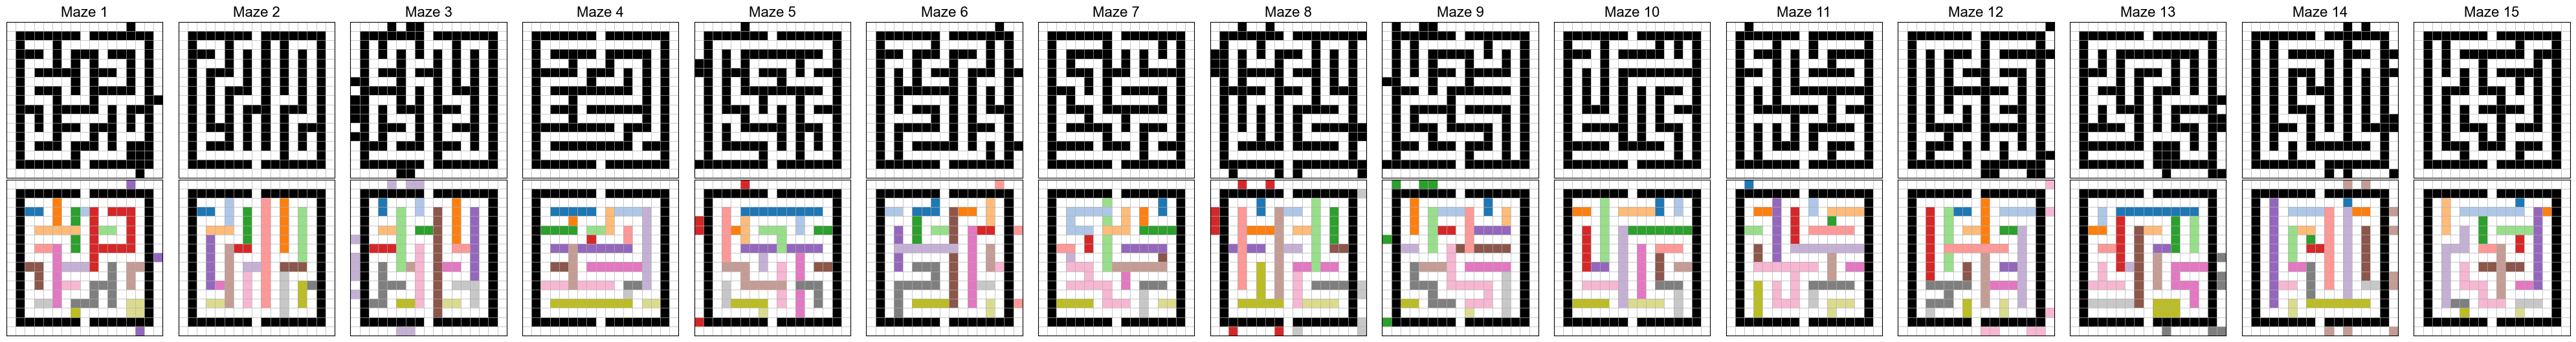

In [3]:
# Visulize VGC maze wall square chunking
def plot_mazes_wall_chunks(
    original_mazes,
    relabeled_mazes,
    figsize=None,
    title_original="Maze",
    title_chunked="",
):
    """
    Visualize multiple original / relabeled maze pairs in a 2 x n_mazes layout.

    Parameters
    ----------
    original_mazes : list[list[str]]
        List of original mazes. Each maze is a list of strings.
    relabeled_mazes : list[list[str]]
        List of relabeled mazes. Same length/order as original_mazes.
    figsize : tuple or None
        Figure size. If None, chosen automatically based on number of mazes.
    title_original : str
        Base title for row 1.
    title_chunked : str
        Base title for row 2.
    """

    n_mazes = len(original_mazes)

    if len(relabeled_mazes) != n_mazes:
        raise ValueError("original_mazes and relabeled_mazes must have the same length.")

    if n_mazes == 0:
        raise ValueError("No mazes provided.")

    # Check all mazes have same dimensions
    H = len(original_mazes[0])
    W = len(original_mazes[0][0])

    for i in range(n_mazes):
        if len(original_mazes[i]) != H or len(original_mazes[i][0]) != W:
            raise ValueError("All original mazes must have the same dimensions.")
        if len(relabeled_mazes[i]) != H or len(relabeled_mazes[i][0]) != W:
            raise ValueError("All relabeled mazes must have the same dimensions.")

    if figsize is None:
        figsize = (4 * n_mazes / 1.5, 8/1.5)

    fig, axes = plt.subplots(2, n_mazes, figsize=figsize, squeeze=False)

    def setup_ax(ax, title):
        ax.set_xlim(0, W)
        ax.set_ylim(H, 0)
        ax.set_aspect("equal")
        ax.set_xticks(np.arange(0, W + 1, 1))
        ax.set_yticks(np.arange(0, H + 1, 1))
        ax.grid(True, which="both", linewidth=0.5)
        ax.set_title(title, fontsize=16)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    def base_facecolor(ch):
        if ch == '#':
            return "black"
        elif ch == '.':
            return "white"
        elif ch == 'S':
            return "white" #"#b7e1cd"   # pale green
        elif ch == 'G':
            return "white" #"#f4cccc"   # pale red
        else:
            return "white" #"#d9d9d9"

    protected_chars = {'#', '.', 'S', 'G'}

    for i in range(n_mazes):
        original_maze = original_mazes[i]
        relabeled_maze = relabeled_mazes[i]

        ax_orig = axes[0, i]
        ax_relb = axes[1, i]

        setup_ax(ax_orig, f"{title_original} {i+1}")
        setup_ax(ax_relb, f"")

        orig = [list(row) for row in original_maze]
        relb = [list(row) for row in relabeled_maze]

        # Infer chunk symbols directly from relabeled maze
        chunk_symbols = sorted({
            relb[r][c]
            for r in range(H)
            for c in range(W)
            if relb[r][c] not in protected_chars
        })

        cmap = plt.get_cmap("tab20")
        if len(chunk_symbols) > 20:
            cmap = plt.get_cmap("gist_ncar")

        symbol_to_idx = {sym: j for j, sym in enumerate(chunk_symbols)}

        # Row 1: original maze
        for r in range(H):
            for c in range(W):
                ch = orig[r][c]
                rect = patches.Rectangle(
                    (c, r), 1, 1,
                    facecolor=base_facecolor(ch),
                    edgecolor="none"
                )
                ax_orig.add_patch(rect)

        # Row 2: relabeled maze
        for r in range(H):
            for c in range(W):
                ch = relb[r][c]

                if ch in protected_chars:
                    facecolor = base_facecolor(ch)
                else:
                    facecolor = cmap(symbol_to_idx[ch] % cmap.N)

                rect = patches.Rectangle(
                    (c, r), 1, 1,
                    facecolor=facecolor,
                    edgecolor="none"
                )
                ax_relb.add_patch(rect)
                
    #fig.suptitle("Chunked mazes for VGC exhaustive search")
    plt.tight_layout()
    
    
plot_mazes_wall_chunks(
    original_mazes=mazes_orig,
    relabeled_mazes=mazes,
)
# plt.savefig(os.path.join("fig","exp1_vgc_chunked_mazes.png"), dpi=300)
plt.savefig(os.path.join("fig","exp1_vgc_chunked_mazes.pdf"), bbox_inches="tight")
plt.show()

In [4]:
# Sanity check: dangerous square count, and merged obstacle count
nums_dangerous_squares = []
for maze_idx in range(len(mazes)):
    grid = mazes[maze_idx]

    # Count characters that are not '.'
    non_dot_count = sum(1 for string in grid for char in string if char != '.')
    nums_dangerous_squares.append(non_dot_count)

    
    # Extract all unique lowercase letters from the grid
    letters = {char for row in grid for char in row if char.islower()}
    # Find the letter closest to 'z'
    closest_to_z = max(letters) if letters else None
    
    print(f"#Dangerous squares: {non_dot_count}; #merged obstacles: {closest_to_z}")

nums_dangerous_squares = np.array(nums_dangerous_squares)
print(np.mean(nums_dangerous_squares), np.std(nums_dangerous_squares, ddof=1)/np.sqrt(len(mazes)))

#Dangerous squares: 133; #merged obstacles: r
#Dangerous squares: 128; #merged obstacles: r
#Dangerous squares: 138; #merged obstacles: r
#Dangerous squares: 128; #merged obstacles: r
#Dangerous squares: 132; #merged obstacles: r
#Dangerous squares: 131; #merged obstacles: r
#Dangerous squares: 128; #merged obstacles: r
#Dangerous squares: 141; #merged obstacles: r
#Dangerous squares: 133; #merged obstacles: r
#Dangerous squares: 128; #merged obstacles: r
#Dangerous squares: 129; #merged obstacles: r
#Dangerous squares: 135; #merged obstacles: r
#Dangerous squares: 136; #merged obstacles: r
#Dangerous squares: 137; #merged obstacles: r
#Dangerous squares: 128; #merged obstacles: r
132.33333333333334 1.106976433984403


# Computational cost comparison (use cluster version)

In [5]:
with open(os.path.join("data",'test_mazes_chunked.pkl'), 'rb') as file:
    mazes = pickle.load(file)

## Annotate best paths under each construal---is it successful / on the rim?

In [6]:
def load_single_result(filepath):
    with open(filepath, "rb") as file:
        return pickle.load(file)


def compute_rim_mask(shape, rim_rows=(0, 16), rim_cols=(0, 16)):
    mask = np.zeros(shape, dtype=bool)

    for r in rim_rows:
        if 0 <= r < shape[0]:
            mask[r, :] = True

    for c in rim_cols:
        if 0 <= c < shape[1]:
            mask[:, c] = True

    return mask


def rim_visit_proportion_from_occ(occ, rim_mask):
    total_visits = np.sum(occ)
    if total_visits == 0:
        return np.nan
    return np.sum(occ[rim_mask]) / total_visits


# =========================================================
# Path-based helpers
# Note: these operate directly on path tuples as stored in
# results[maze_idx]["paths"], i.e. in the same coordinate
# system as (8,0), (7,0), ..., (8,14).
# =========================================================
def build_rim_coordinate_set(max_coord=16):
    """
    Coordinates are treated as (x, y).
    Rim means x in {0,16} or y in {0,16}.
    """
    return {
        (x, y)
        for x in range(max_coord + 1)
        for y in range(max_coord + 1)
        if (x == 0 or x == max_coord or y == 0 or y == max_coord)
    }


def build_two_full_rim_routes(max_coord=16):
    """
    Construct the two canonical full rim routes described by you.

    Entry point on rim:  (8, 0)
    Exit point near goal: (8, 14)

    Route A:
      (8,0) -> left along top edge to (0,0)
             -> down left edge to (0,16)
             -> right along bottom edge to (8,16)

    Route B:
      (8,0) -> right along top edge to (16,0)
             -> down right edge to (16,16)
             -> left along bottom edge to (8,16)

    Returns
    -------
    route_left, route_right : sets of (x, y)
    """
    # Left route
    route_left = set()

    # top edge: (8,0) -> (0,0)
    for x in range(0, 9):
        route_left.add((x, 0))

    # left edge: (0,0) -> (0,16)
    for y in range(0, max_coord + 1):
        route_left.add((0, y))

    # bottom edge: (0,16) -> (8,16)
    for x in range(0, 9):
        route_left.add((x, max_coord))

    # Right route
    route_right = set()

    # top edge: (8,0) -> (16,0)
    for x in range(8, max_coord + 1):
        route_right.add((x, 0))

    # right edge: (16,0) -> (16,16)
    for y in range(0, max_coord + 1):
        route_right.add((max_coord, y))

    # bottom edge: (16,16) -> (8,16)
    for x in range(8, max_coord + 1):
        route_right.add((x, max_coord))

    return route_left, route_right


def label_full_rim_route(path, route_left, route_right):
    """
    Label 1 iff the path contains all coordinates of either full rim route.
    """
    path_set = set(path)
    return int(route_left.issubset(path_set) or route_right.issubset(path_set))

def path_on_rim(path, route_left, route_right):
    """
    Label 1 iff the path only contains rim squares, start, and goal.
    """
    # Add start and goal. 
    start_goal_pos = {(8,1),(8,15)}
    rim_routes = route_left | route_right | start_goal_pos
    path_set = set(path)
    return int(path_set.issubset(rim_routes))

route_left, route_right = build_two_full_rim_routes(max_coord=16)

In [7]:
# Load VGC construals and corresponding paths, as simulated on the cluster.
for maze_idx_temp in range(len(mazes)):
    maze_name_temp = list(mazes.keys())[maze_idx_temp]
    maze = mazes[maze_name_temp]

    with open(os.path.join("model_preds","vgc","vgc_shared_"+str(maze_idx_temp)+".pkl"), 'rb') as file:
        res = pickle.load(file)

    construals_bestpaths = res.construals_bestpaths
    construals_bestpaths_pathonrim = {}
    construals_bestpaths_success = {}

    for construal, best_path in construals_bestpaths.items():
        # If the path only traverses 
        construals_bestpaths_pathonrim[construal] = path_on_rim(best_path, route_left, route_right)
        construals_bestpaths_success[construal] = int(path_eval_success(best_path, maze))

    mean_pathonrim = np.array(list(construals_bestpaths_pathonrim.values())).mean()
    mean_success = np.array(list(construals_bestpaths_success.values())).mean()
    
    # VGC never uses rim paths (assuming optimal-path-taking on its selected construals)
    print(maze_idx_temp, mean_pathonrim, mean_success, len(list(res.max_construals_utilities.keys())[0]))


0 0.0 0.108642578125 4
1 0.0 0.125 4
2 0.0 0.09375 5
3 0.0 0.0850830078125 7
4 0.0 0.0439453125 10
5 0.0 0.05859375 3
6 0.0 0.0078125 9
7 0.0 0.01171875 7
8 0.0 0.0347900390625 7
9 0.0 0.017578125 6
10 0.0 0.0625 4
11 0.0 0.0263671875 6
12 0.0 0.046875 8
13 0.0 0.11328125 5
14 0.0 0.01953125 8


start = (8, 15)
goal  = (8, 1)


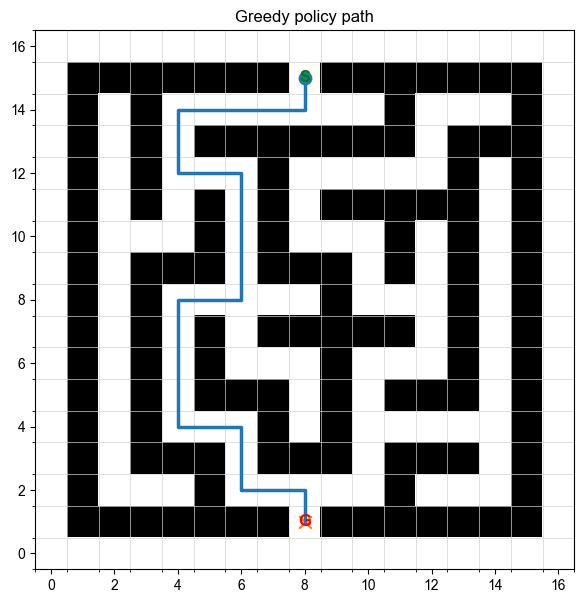

In [8]:
# Sanity check

from matplotlib.colors import ListedColormap


def plot_maze_with_path(maze, path, title="Policy rollout"):
    """
    Plot maze so axes are in Cartesian coordinates:
    bottom-left = (0,0)
    """
    H = len(maze)
    W = len(maze[0])

    # Build display grid in Cartesian y-order:
    # grid[y, x] with y=0 at bottom
    grid = np.zeros((H, W), dtype=int)
    for x in range(W):
        for y in range(H):
            row, col = xy_to_rowcol(maze, x, y)
            grid[y, x] = 0 if maze[row][col] in {'.', 'S', 'G'} else 1

    fig, ax = plt.subplots(figsize=(7, 7))
    cmap = ListedColormap(["white", "black"])

    # origin='lower' makes (0,0) appear bottom-left visually
    ax.imshow(grid, cmap=cmap, origin="lower")

    # write S and G in Cartesian coordinates
    for x in range(W):
        for y in range(H):
            row, col = xy_to_rowcol(maze, x, y)
            ch = maze[row][col]
            if ch == 'S':
                ax.text(x, y, 'S', ha='center', va='center',
                        color='green', fontsize=12, fontweight='bold')
            elif ch == 'G':
                ax.text(x, y, 'G', ha='center', va='center',
                        color='red', fontsize=12, fontweight='bold')

    if len(path) > 0:
        xs = [p[0] for p in path]
        ys = [p[1] for p in path]
        ax.plot(xs, ys, linewidth=2.5)
        ax.scatter(xs[0], ys[0], s=80, marker='o')
        ax.scatter(xs[-1], ys[-1], s=80, marker='x')

    ax.set_xticks(np.arange(-0.5, W, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, H, 1), minor=True)
    ax.grid(which="minor", color="lightgray", linewidth=0.5)

    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(-0.5, H - 0.5)
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.show()
    
    
    
# maze = mazes[maze_name]
start = find_char(maze, 'S')
goal = find_char(maze, 'G')
best_path = construals_bestpaths[list(construals_bestpaths.keys())[-1]]

print("start =", start)
print("goal  =", goal)

plot_maze_with_path(maze, best_path, title="Greedy policy path")

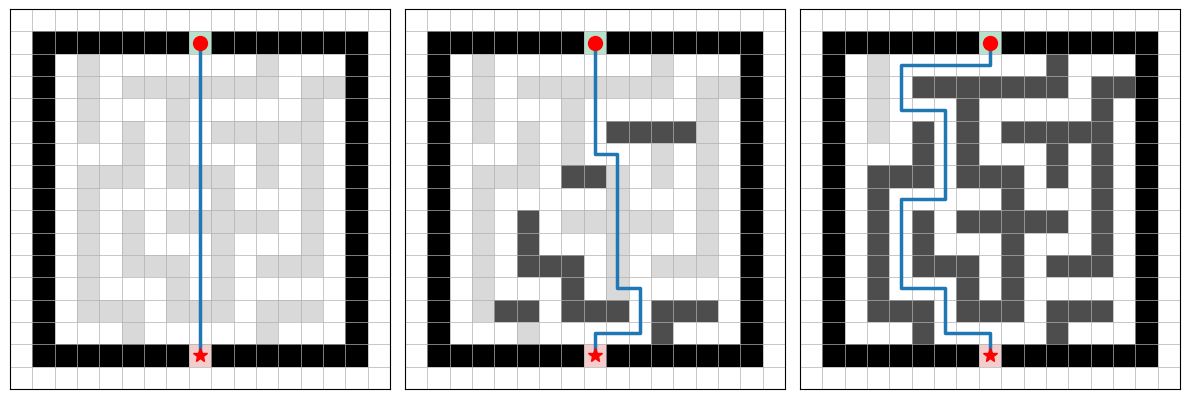

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def plot_construals_bestpaths(
    maze,
    construals_bestpaths,
    keys_to_plot,
    figsize=None,
    path_color="C0",
    path_linewidth=2.5,
    show_titles=True,
):
    """
    Plot selected construals and their corresponding best paths on a maze.

    Parameters
    ----------
    maze : list[str]
        Maze as list of strings.
    construals_bestpaths : dict[frozenset, list[tuple[int, int]]]
        Mapping from construal (frozenset of letters) to best path
        (list of (x, y) or (col, row)-style coordinates).
    keys_to_plot : list[frozenset]
        Which construal keys to visualize.
    figsize : tuple or None
        Figure size. If None, chosen automatically from number of keys.
    path_color : str
        Color of overlaid best path.
    path_linewidth : float
        Width of path line.
    show_titles : bool
        Whether to show subplot titles.
    """

    if len(keys_to_plot) == 0:
        raise ValueError("keys_to_plot is empty.")

    H = len(maze)
    W = len(maze[0])

    for row in maze:
        if len(row) != W:
            raise ValueError("All maze rows must have the same length.")

    n_keys = len(keys_to_plot)

    if figsize is None:
        figsize = (4 * n_keys, 4.8)

    fig, axes = plt.subplots(1, n_keys, figsize=figsize, squeeze=False)
    axes = axes[0]

    maze_grid = [list(row) for row in maze]

    def setup_ax(ax, title=None):
        ax.set_xlim(0, W)
        ax.set_ylim(H, 0)
        ax.set_aspect("equal")
        ax.set_xticks(np.arange(0, W + 1, 1))
        ax.set_yticks(np.arange(0, H + 1, 1))
        ax.grid(True, which="both", linewidth=0.5)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        if title is not None:
            ax.set_title(title, fontsize=10)

    def cell_facecolor(ch, construal):
        # Standard maze parts
        if ch == '#':
            return "black"
        elif ch == '.':
            return "white"
        elif ch == 'S':
            return "#b7e1cd"   # pale green
        elif ch == 'G':
            return "#f4cccc"   # pale red

        # Internal lettered obstacles
        elif ch.isalpha():
            if ch in construal:
                return "#4d4d4d"   # dark gray for represented obstacles
            else:
                return "#d9d9d9"   # light gray for omitted obstacles

        # Fallback
        return "white"

    for ax, construal in zip(axes, keys_to_plot):
        if construal not in construals_bestpaths:
            raise KeyError(f"Key not found in construals_bestpaths: {construal}")

        path = construals_bestpaths[construal]

        title = None
        if show_titles:
            if len(construal) == 0:
                title = "{ }"
            else:
                title = "{" + ", ".join(sorted(construal)) + "}"
    
        setup_ax(ax, title)

        # Draw maze cells
        for r in range(H):
            for c in range(W):
                ch = maze_grid[r][c]
                facecolor = cell_facecolor(ch, construal)

                rect = patches.Rectangle(
                    (c, r), 1, 1,
                    facecolor=facecolor,
                    edgecolor="none"
                )
                ax.add_patch(rect)

        # Overlay best path
        if path is not None and len(path) > 0:
            # (x, y) = (col, row)
            xs = [p[0] + 0.5 for p in path]
            ys = [16-p[1] + 0.5 for p in path]

            ax.plot(
                xs, ys,
                color=path_color,
                linewidth=path_linewidth,
                zorder=5
            )

            # Mark start/end of path
            ax.plot(xs[0], ys[0], marker='o', markersize=10, color="r", zorder=6)
            ax.plot(xs[-1], ys[-1], marker='*', markersize=10, color="r", zorder=6)

    plt.tight_layout()
    
construals = list(construals_bestpaths.keys())
keys_to_plot = [
    construals[0],
    construals[30000],
    construals[-5]
]

plot_construals_bestpaths(
    maze=maze,
    construals_bestpaths=construals_bestpaths,
    keys_to_plot=keys_to_plot,
    show_titles=False
)
# plt.savefig(os.path.join("fig","exp1_vgc_solutions_examples.png"), dpi=300)
plt.savefig(os.path.join("fig","exp1_vgc_solutions_examples.pdf"), bbox_inches=False)
plt.show()